# Grounding DINO capability and score semantics

This notebook answers a narrow question: **what does our current Grounding DINO + SAM pipeline actually do, and what do its scores mean?**

It is a one-image diagnostic, not a model benchmark. The goal is to make each pipeline step visible and to identify the next experiment we need.

## Questions and hypotheses

1. Can Grounding DINO Tiny locate an obvious leaf well enough to provide a box to SAM, even when its score is well below 0.9?
2. What is the value currently called `detection_confidence`? Is it a probability that the region is a leaf?
3. How do box and text thresholds change the returned results?
4. How sensitive is localization to simple changes in the text prompt?
5. Which later scores come from a model, and which are heuristics written in our application?

**Working hypothesis:** Grounding DINO should be used to propose the location of visible plant organs. SAM should refine the geometry. A separate downstream classifier should assign botanical feature values.

## What the current model was trained to do

The current detector is `IDEA-Research/grounding-dino-tiny`. It combines a Swin-T image backbone, a BERT text backbone, and a transformer detector. It was trained with object-detection and grounded image-text data (Objects365, GoldG, and Cap4M). It learns relationships between text tokens or phrases and image regions. It is not a visual question-answering model and it is not a botanical feature classifier.

There is no small closed list of every word it can accept. Common object names and referring expressions are valid inputs, but rare botanical language must be tested empirically.

Primary sources: [Grounding DINO paper](https://arxiv.org/abs/2303.05499), [official repository and checkpoint table](https://github.com/IDEA-Research/GroundingDINO), and [Hugging Face model card](https://huggingface.co/IDEA-Research/grounding-dino-tiny).

In [1]:
from pathlib import Path
import gc
import json
import platform
import sys
import time

import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from PIL import Image
import torch
import transformers
from IPython.display import Markdown, display
from transformers import (
    AutoModelForZeroShotObjectDetection,
    AutoProcessor,
    Sam2Model,
    Sam2Processor,
)
from transformers.utils import logging as transformers_logging

transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

IMAGE_PATH = ROOT / 'notebooks/assets/grounding_dino_clear_leaf_example.jpg'
FAILURE_IMAGE_PATH = ROOT / 'notebooks/assets/grounding_dino_false_leaf_example.jpg'
PREVIOUS_ARTIFACT = ROOT / 'artifacts/grounded-sam-hello-world-v2.json'
DETECTOR_ID = 'IDEA-Research/grounding-dino-tiny'
SAM_ID = 'facebook/sam2.1-hiera-tiny'
DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)

metadata = {
    'python': platform.python_version(),
    'torch': torch.__version__,
    'transformers': transformers.__version__,
    'device': DEVICE,
    'detector': DETECTOR_ID,
    'segmenter': SAM_ID,
    'positive image': str(IMAGE_PATH.relative_to(ROOT)),
    'failure image': str(FAILURE_IMAGE_PATH.relative_to(ROOT)),
}
pd.DataFrame(metadata.items(), columns=['setting', 'value'])

,setting,value
0,python,3.12.10
1,torch,2.13.0
2,transformers,5.14.1
3,device,mps
4,detector,IDEA-Research/grounding-dino-tiny
5,segmenter,facebook/sam2.1-hiera-tiny
6,positive image,notebooks/assets/grounding_dino_clear_leaf_exa...
7,failure image,notebooks/assets/grounding_dino_false_leaf_exa...


## 1. Fixed input image

The primary input is an unambiguous sweetgum leaf from the project's Pound Ridge iNaturalist corpus (`observation_id=188544116`, `photo_id=330028572`). A separate earlier flower image is examined later as a failure case.

Image size: 1536 × 2048 pixels


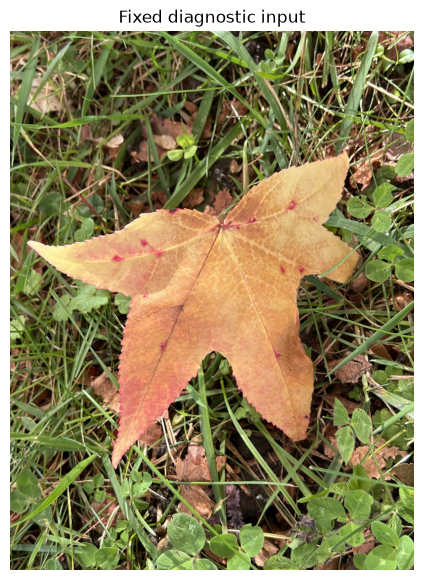

In [2]:
assert IMAGE_PATH.exists(), f'Missing input image: {IMAGE_PATH}'
image = Image.open(IMAGE_PATH).convert('RGB')
print(f'Image size: {image.width} × {image.height} pixels')
plt.figure(figsize=(9, 7))
plt.imshow(image)
plt.title('Fixed diagnostic input')
plt.axis('off')
plt.show()

## 2. What prompt does the model actually receive?

The official recommendation is to use lowercase category names separated by periods. In our code we pass a nested list such as `[['leaf', 'flower']]`. The Hugging Face processor lowercases and merges this into `leaf. flower.` automatically.

In [3]:
processor = AutoProcessor.from_pretrained(DETECTOR_ID, local_files_only=True)
candidate_labels = [['leaf', 'flower', 'fruit', 'stem', 'bark']]
prompt_demo_inputs = processor(images=image, text=candidate_labels, return_tensors='pt')
actual_tokens = processor.tokenizer.convert_ids_to_tokens(prompt_demo_inputs.input_ids[0])
actual_text = processor.tokenizer.decode(prompt_demo_inputs.input_ids[0], skip_special_tokens=True)
display(pd.DataFrame({
    'item': ['Python input', 'Decoded model text', 'BERT tokens'],
    'value': [str(candidate_labels[0]), actual_text, str(actual_tokens)],
}))

,item,value
0,Python input,"['leaf', 'flower', 'fruit', 'stem', 'bark']"
1,Decoded model text,leaf. flower. fruit. stem. bark.
2,BERT tokens,"['[CLS]', 'leaf', '.', 'flower', '.', 'fruit',..."


## 3. Raw Grounding DINO output

Grounding DINO produces 900 candidate object queries by default. Each query has a box and a score against every text-token position. The post-processor applies `sigmoid` to the logits and uses the **largest token score for each query** to rank and filter boxes.

Therefore, the returned score is best described as a **query–text alignment score**. It is not a calibrated probability that a box contains a leaf. The exact implementation is visible in the [official Transformers processor](https://github.com/huggingface/transformers/blob/v5.14.0/src/transformers/models/grounding_dino/processing_grounding_dino.py).

In [4]:
model = AutoModelForZeroShotObjectDetection.from_pretrained(
    DETECTOR_ID, local_files_only=True
).to(DEVICE)
model.eval()

baseline_labels = [['leaf']]
baseline_inputs = processor(
    images=image, text=baseline_labels, return_tensors='pt'
).to(DEVICE)

start = time.perf_counter()
with torch.inference_mode():
    baseline_outputs = model(**baseline_inputs)
baseline_runtime = time.perf_counter() - start

print('Raw logits shape:   ', tuple(baseline_outputs.logits.shape))
print('Raw boxes shape:    ', tuple(baseline_outputs.pred_boxes.shape))
print(f'Inference runtime:   {baseline_runtime:.2f} seconds')
print('Raw box format:      normalized [center_x, center_y, width, height]')

Raw logits shape:    (1, 900, 256)
Raw boxes shape:     (1, 900, 4)
Inference runtime:   2.16 seconds
Raw box format:      normalized [center_x, center_y, width, height]


In [5]:
probabilities = torch.sigmoid(baseline_outputs.logits[0]).detach().cpu()
query_scores, best_token_indices = probabilities.max(dim=-1)
raw_boxes = baseline_outputs.pred_boxes[0].detach().cpu()
top_query_indices = torch.argsort(query_scores, descending=True)[:10]
input_token_ids = baseline_inputs.input_ids[0].detach().cpu().tolist()

def token_at(index):
    if index < len(input_token_ids):
        return processor.tokenizer.convert_ids_to_tokens(input_token_ids[index])
    return '[masked/padded position]'

top_rows = []
for rank, query_index in enumerate(top_query_indices.tolist(), start=1):
    token_index = int(best_token_indices[query_index])
    cx, cy, width, height = raw_boxes[query_index].tolist()
    top_rows.append({
        'rank': rank,
        'query_id': query_index,
        'best_token': token_at(token_index),
        'query_text_score': float(query_scores[query_index]),
        'center_x': cx, 'center_y': cy, 'width': width, 'height': height,
    })
top_queries_df = pd.DataFrame(top_rows)
top_queries_df.style.format({
    'query_text_score': '{:.4f}', 'center_x': '{:.3f}', 'center_y': '{:.3f}',
    'width': '{:.3f}', 'height': '{:.3f}',
})

,rank,query_id,best_token,query_text_score,center_x,center_y,width,height
0,1,0,leaf,0.7769,0.454,0.518,0.827,0.591
1,2,1,leaf,0.2284,0.435,0.933,0.098,0.081
2,3,2,leaf,0.1982,0.598,0.945,0.064,0.065
3,4,3,leaf,0.1768,0.784,0.897,0.100,0.069
4,5,13,leaf,0.1702,0.529,0.955,0.075,0.047
5,6,18,leaf,0.1519,0.827,0.768,0.052,0.076
6,7,43,leaf,0.1498,0.863,0.880,0.074,0.062
7,8,20,leaf,0.1482,0.928,0.933,0.073,0.050
8,9,5,leaf,0.1383,0.426,0.216,0.078,0.053
9,10,11,leaf,0.1358,0.870,0.733,0.056,0.069


### Interpretation

A score such as 0.35 means that this object query has a maximum sigmoid alignment score of 0.35 with an input token. It does **not** mean “35% probability that this is a leaf.” A threshold decides which proposals we keep; it does not turn the score into a calibrated probability.

## 4. Box-threshold sweep

We reuse exactly the same raw inference output and change only the box threshold. `text_threshold` remains fixed at 0.20. This isolates post-processing from model inference.

In [6]:
def postprocess_to_cpu(outputs, inputs, threshold, text_threshold=0.20):
    result = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=threshold,
        text_threshold=text_threshold,
        target_sizes=[(image.height, image.width)],
    )[0]
    return {
        'scores': result['scores'].detach().cpu(),
        'boxes': result['boxes'].detach().cpu(),
        'text_labels': list(result['text_labels']),
    }

box_thresholds = [0.15, 0.25, 0.35, 0.50]
threshold_results = {
    threshold: postprocess_to_cpu(baseline_outputs, baseline_inputs, threshold)
    for threshold in box_thresholds
}

threshold_rows = []
for threshold, result in threshold_results.items():
    count = len(result['scores'])
    threshold_rows.append({
        'box_threshold': threshold,
        'boxes_retained': count,
        'top_score': float(result['scores'].max()) if count else None,
        'top_phrase': result['text_labels'][int(result['scores'].argmax())] if count else None,
    })
threshold_df = pd.DataFrame(threshold_rows)
threshold_df.style.format({'box_threshold': '{:.2f}', 'top_score': '{:.4f}'}, na_rep='—')

,box_threshold,boxes_retained,top_score,top_phrase
0,0.15,6,0.7769,leaf
1,0.25,1,0.7769,leaf
2,0.35,1,0.7769,leaf
3,0.50,1,0.7769,leaf


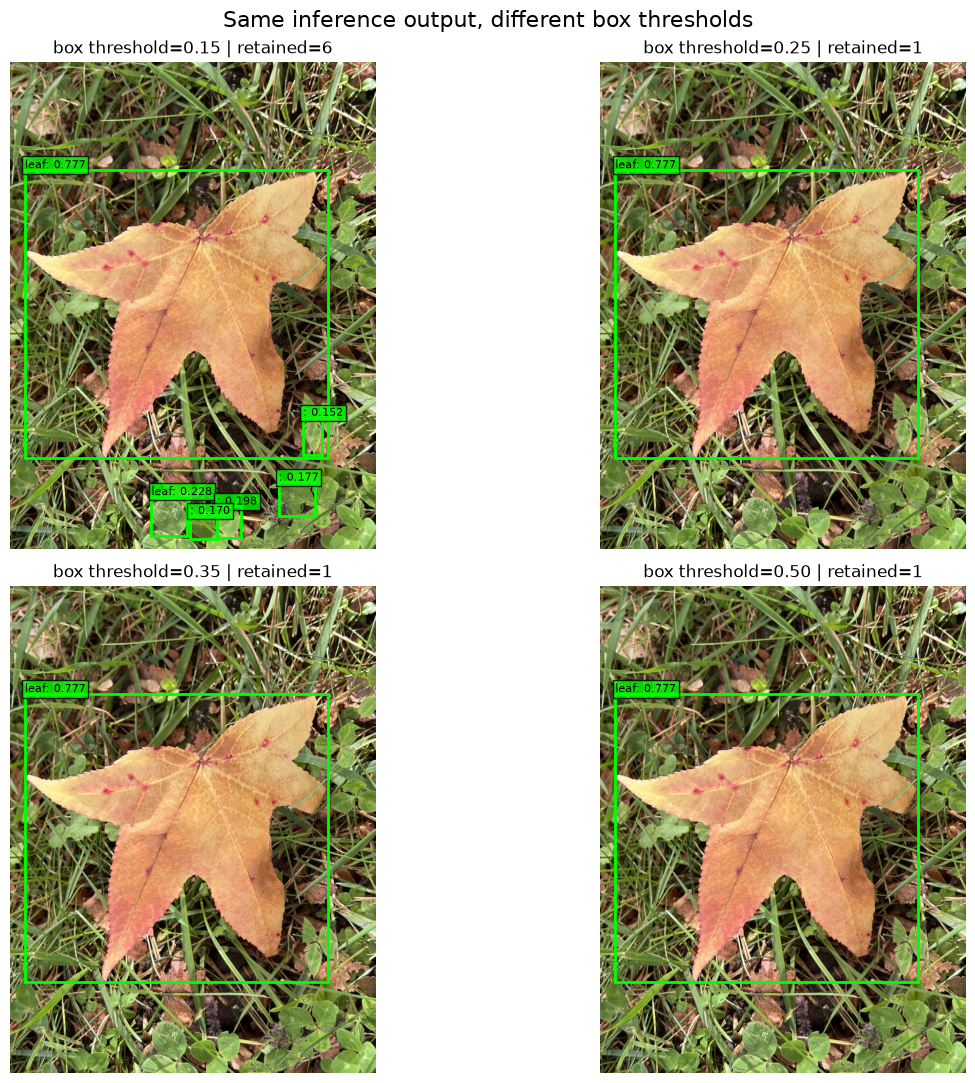

In [7]:
def draw_result(ax, result, title, max_boxes=8):
    ax.imshow(image)
    if len(result['scores']):
        order = torch.argsort(result['scores'], descending=True)[:max_boxes]
        for item_index in order.tolist():
            x0, y0, x1, y1 = result['boxes'][item_index].tolist()
            score = float(result['scores'][item_index])
            label = result['text_labels'][item_index]
            ax.add_patch(Rectangle(
                (x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='lime', linewidth=2
            ))
            ax.text(
                x0, max(0, y0 - 8), f'{label}: {score:.3f}', color='black', fontsize=8,
                bbox={'facecolor': 'lime', 'alpha': 0.8, 'pad': 2},
            )
    ax.set_title(title)
    ax.axis('off')

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, threshold in zip(axes.flat, box_thresholds):
    result = threshold_results[threshold]
    draw_result(
        ax, result, f'box threshold={threshold:.2f} | retained={len(result["scores"])}'
    )
plt.suptitle('Same inference output, different box thresholds', fontsize=16)
plt.tight_layout()
plt.show()

**Key point:** the box threshold controls a recall/precision trade-off. A high threshold can remove a useful proposal even when SAM could have produced an excellent mask from that box.

## 5. Small prompt ablation

This is not prompt optimization. It is a sensitivity check using ordinary object-language variants. All cases use the same image, model, box threshold (0.15), and text threshold (0.20). Scores from different prompts are not calibrated probabilities and should not be treated as directly comparable confidence estimates.

In [8]:
prompt_conditions = [
    ['leaf'],
    ['a leaf'],
    ['leaves'],
    ['plant leaf'],
    ['the large leaf in the foreground'],
    ['leaf', 'flower', 'fruit', 'stem', 'bark'],
]

prompt_rows = []
prompt_results = {}
for labels in prompt_conditions:
    actual_merged_text = '. '.join(item.strip().lower() for item in labels) + '.'
    if labels == ['leaf']:
        condition_inputs = baseline_inputs
        condition_outputs = baseline_outputs
        runtime = baseline_runtime
    else:
        condition_inputs = processor(
            images=image, text=[labels], return_tensors='pt'
        ).to(DEVICE)
        start = time.perf_counter()
        with torch.inference_mode():
            condition_outputs = model(**condition_inputs)
        runtime = time.perf_counter() - start
    result = postprocess_to_cpu(condition_outputs, condition_inputs, threshold=0.15)
    prompt_results[actual_merged_text] = result
    count = len(result['scores'])
    top_index = int(result['scores'].argmax()) if count else None
    prompt_rows.append({
        'candidate_labels': str(labels),
        'actual_model_text': actual_merged_text,
        'boxes_retained': count,
        'top_score': float(result['scores'][top_index]) if count else None,
        'top_phrase': result['text_labels'][top_index] if count else None,
        'runtime_seconds': runtime,
    })

prompt_df = pd.DataFrame(prompt_rows)
prompt_df.style.format({
    'top_score': '{:.4f}', 'runtime_seconds': '{:.2f}',
}, na_rep='—')

,candidate_labels,actual_model_text,boxes_retained,top_score,top_phrase,runtime_seconds
0,['leaf'],leaf.,6,0.7769,leaf,2.16
1,['a leaf'],a leaf.,5,0.7816,a leaf,1.06
2,['leaves'],leaves.,9,0.7264,leaves,1.01
3,['plant leaf'],plant leaf.,5,0.7856,plant leaf,0.99
4,['the large leaf in the foreground'],the large leaf in the foreground.,1,0.8623,the large leaf,1.05
5,"['leaf', 'flower', 'fruit', 'stem', 'bark']",leaf. flower. fruit. stem. bark.,5,0.5631,leaf,1.04


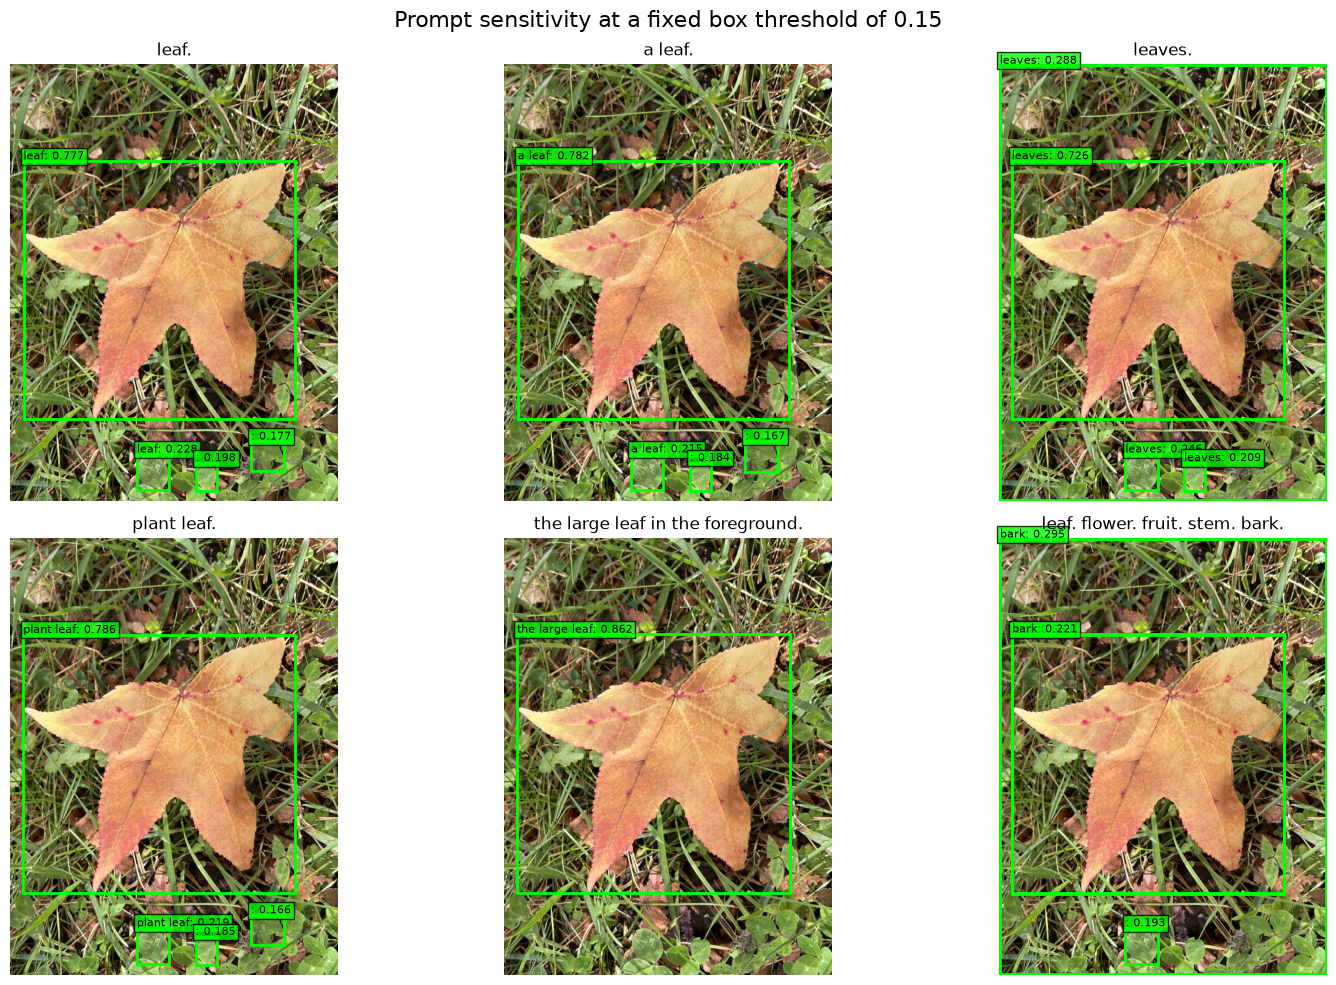

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, labels in zip(axes.flat, prompt_conditions):
    actual_text = '. '.join(item.strip().lower() for item in labels) + '.'
    draw_result(ax, prompt_results[actual_text], actual_text, max_boxes=4)
plt.suptitle('Prompt sensitivity at a fixed box threshold of 0.15', fontsize=16)
plt.tight_layout()
plt.show()

### How to read this result

This one-image table is a sensitivity check, not a prompt leaderboard. We care about whether the returned geometry stays on the intended organ, how many extra proposals appear, and whether multiple candidate labels compete with one another. A larger score alone does not establish that a prompt is better.

In this run, `leaf`, `a leaf`, `leaves`, and `plant leaf` all returned the main leaf. The referring expression `the large leaf in the foreground` retained one focused proposal and had the largest score (`0.862`). The combined organ prompt still found the leaf, but its top score fell to `0.563` and it also introduced large false `bark` regions. This is useful evidence that prompt context changes both semantic labels and geometry, but one image is not enough to select a production prompt.

### Prompt recommendation for the current organ-localization stage

Start with simple, lowercase, visually concrete organ names: `leaf`, `flower`, `fruit`, `stem`, `bark`, `bud`, `branch`, and `whole plant`. Separate multiple candidates with periods; the current processor already does this.

Referring expressions are an interesting capability to test, especially for cases such as a distinctive fruit behind leaves. Specialized values such as `palmately lobed` should remain exploratory prompts, not final botanical labels, until a labeled evaluation shows that they work reliably.

## 6. SAM mask from the best leaf box

We now pass the best Grounding DINO box to SAM 2.1 Tiny. Grounding DINO chooses **where to look**; SAM refines the region geometry. The returned SAM IoU score is a **predicted mask-quality score**, not an IoU measured against a human annotation.

In [10]:
baseline_result = threshold_results[0.15]
assert len(baseline_result['scores']), 'No leaf box survived threshold 0.15'
best_index = int(baseline_result['scores'].argmax())
best_box = baseline_result['boxes'][best_index]
best_grounding_score = float(baseline_result['scores'][best_index])
best_phrase = baseline_result['text_labels'][best_index]

# Release the DINO model before loading SAM to reduce memory pressure.
del model, baseline_outputs
gc.collect()
if DEVICE == 'mps':
    torch.mps.empty_cache()
elif DEVICE == 'cuda':
    torch.cuda.empty_cache()

sam_processor = Sam2Processor.from_pretrained(SAM_ID, local_files_only=True)
sam_model = Sam2Model.from_pretrained(SAM_ID, local_files_only=True).to(DEVICE)
sam_model.eval()
sam_inputs = sam_processor(
    images=image, input_boxes=[[best_box.tolist()]], return_tensors='pt'
).to(DEVICE)
with torch.inference_mode():
    sam_outputs = sam_model(**sam_inputs, multimask_output=False)
postprocessed_masks = sam_processor.post_process_masks(
    sam_outputs.pred_masks.detach().cpu(), sam_inputs['original_sizes'].detach().cpu()
)[0]
mask = postprocessed_masks[0, 0].numpy().astype(bool)
sam_predicted_iou = float(sam_outputs.iou_scores[0, 0, 0].detach().cpu())

print(f'Best Grounding DINO phrase: {best_phrase}')
print(f'Grounding score:            {best_grounding_score:.4f}')
print(f'SAM predicted IoU:          {sam_predicted_iou:.4f}')
print('Actual mask IoU:            unavailable (no human ground-truth mask)')

Best Grounding DINO phrase: leaf
Grounding score:            0.7769
SAM predicted IoU:          0.9902
Actual mask IoU:            unavailable (no human ground-truth mask)


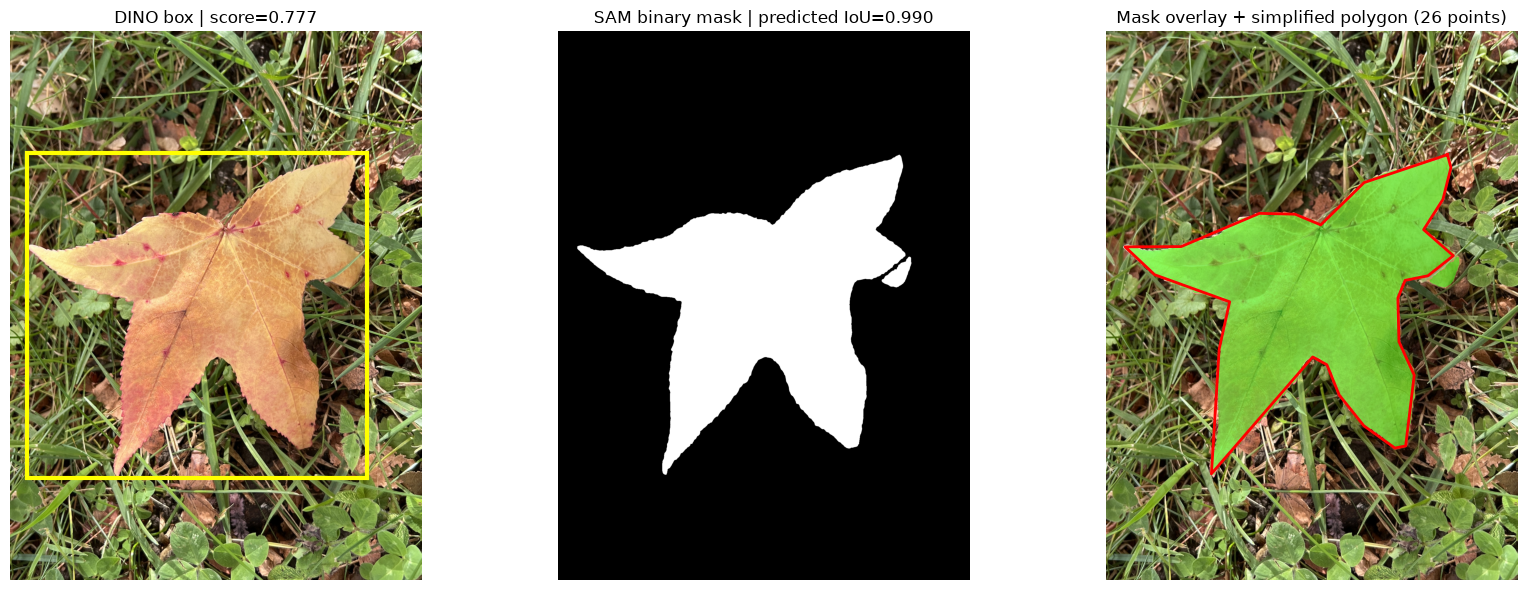

In [11]:
def mask_to_normalized_polygon(binary_mask, epsilon_fraction=0.003):
    contours, _ = cv2.findContours(
        binary_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        return ()
    contour = max(contours, key=cv2.contourArea)
    epsilon = epsilon_fraction * cv2.arcLength(contour, True)
    points = cv2.approxPolyDP(contour, epsilon, True).reshape(-1, 2)
    return tuple((float(x) / image.width, float(y) / image.height) for x, y in points)

polygon = mask_to_normalized_polygon(mask)
polygon_pixels = np.array([
    [x * image.width, y * image.height] for x, y in polygon
])
overlay = np.asarray(image).copy()
green = np.zeros_like(overlay)
green[..., 1] = 255
overlay[mask] = (0.55 * overlay[mask] + 0.45 * green[mask]).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
axes[0].imshow(image)
x0, y0, x1, y1 = best_box.tolist()
axes[0].add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False, edgecolor='yellow', linewidth=3))
axes[0].set_title(f'DINO box | score={best_grounding_score:.3f}')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'SAM binary mask | predicted IoU={sam_predicted_iou:.3f}')
axes[2].imshow(overlay)
if len(polygon_pixels):
    closed = np.vstack([polygon_pixels, polygon_pixels[0]])
    axes[2].plot(closed[:, 0], closed[:, 1], color='red', linewidth=2)
axes[2].set_title(f'Mask overlay + simplified polygon ({len(polygon)} points)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Scores created by our application

The pipeline adds ranking scores after inference. These are useful product heuristics, but they should not be described as model confidence or taxonomic confidence.

In [12]:
from segmentation.pipeline import RawSegment, _quality

raw_segment = RawSegment(
    label='leaf',
    polygon=polygon,
    detection_confidence=best_grounding_score,
    mask_quality=sam_predicted_iou,
    prompt='leaf',
)
quality = _quality(raw_segment)
live_gate_heuristic = 0.5 * best_grounding_score + 0.5 * sam_predicted_iou
score_rows = [
    {
        'name': 'DINO detection_confidence',
        'value': best_grounding_score,
        'meaning': 'Maximum query-to-text-token sigmoid alignment score',
        'kind': 'model output; not calibrated probability',
    },
    {
        'name': 'SAM mask_quality',
        'value': sam_predicted_iou,
        'meaning': 'SAM-predicted IoU for its own mask',
        'kind': 'model-predicted quality; not actual IoU',
    },
    {
        'name': 'stability_score',
        'value': raw_segment.stability_score,
        'meaning': 'Default placeholder currently set to 0.5',
        'kind': 'constant placeholder',
    },
    {
        'name': 'representative_score',
        'value': quality.representative_score,
        'meaning': 'Weighted combination of DINO, SAM, stability, area, and border scores',
        'kind': 'application heuristic',
    },
    {
        'name': 'live gate confidence',
        'value': live_gate_heuristic,
        'meaning': '0.5 × DINO score + 0.5 × SAM predicted IoU',
        'kind': 'application heuristic',
    },
]
score_df = pd.DataFrame(score_rows)
score_df.style.format({'value': '{:.4f}'})

,name,value,meaning,kind
0,DINO detection_confidence,0.7769,Maximum query-to-text-token sigmoid alignment score,model output; not calibrated probability
1,SAM mask_quality,0.9902,SAM-predicted IoU for its own mask,model-predicted quality; not actual IoU
2,stability_score,0.5000,Default placeholder currently set to 0.5,constant placeholder
3,representative_score,0.8551,"Weighted combination of DINO, SAM, stability, area, and border scores",application heuristic
4,live gate confidence,0.8835,0.5 × DINO score + 0.5 × SAM predicted IoU,application heuristic


### Recommended terminology

| Current field | Recommended description |
|---|---|
| `detection_confidence` | Grounding/query–text alignment score |
| `box_threshold` | Query retention cutoff |
| `text_threshold` | Token-to-label extraction cutoff |
| `mask_quality` | SAM predicted IoU |
| `representative_score` | Application ranking heuristic |
| live `confidence` | Application gate heuristic |

If the API must keep existing field names, the documentation should still define them this way.

## 8. Important failure case from the earlier terminal run

Visual inspection showed that the earlier artifact image is a yellow flower, not a leaf. The pipeline nevertheless returned the phrase `leaf`, and SAM accurately segmented the flower. This is exactly why a high-quality mask does not validate the semantic label.

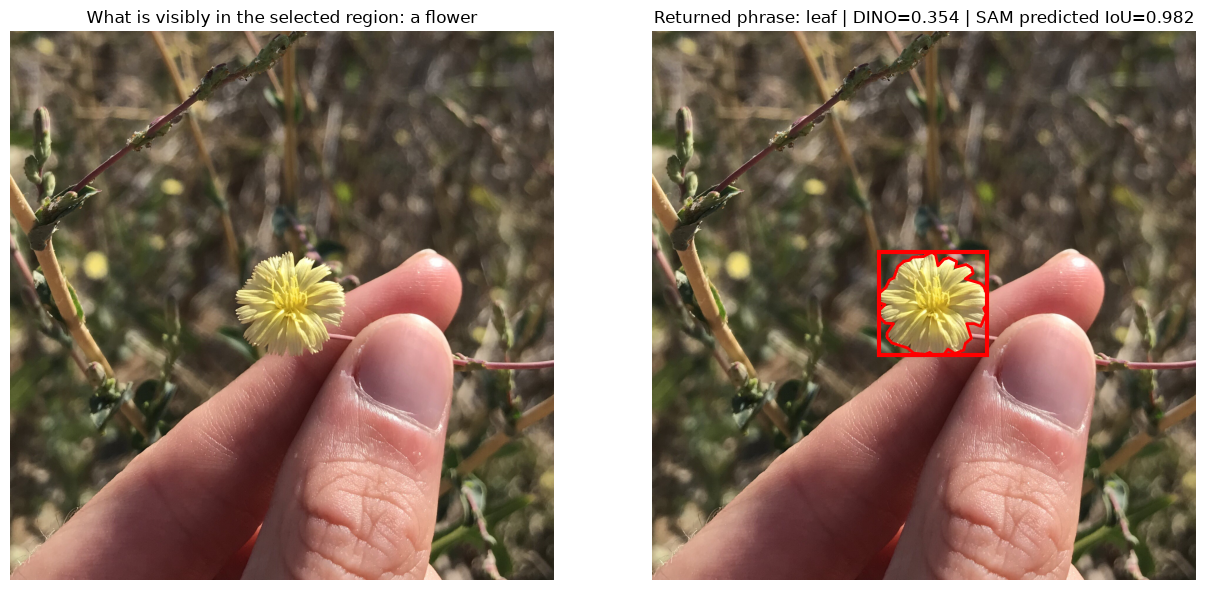

,visible object,returned phrase,DINO grounding score,SAM predicted IoU,representative score,result
0,flower,leaf,0.3542,0.9819,0.7258,semantic false positive with a high-quality mask


In [13]:
assert FAILURE_IMAGE_PATH.exists() and PREVIOUS_ARTIFACT.exists()
failure_image = Image.open(FAILURE_IMAGE_PATH).convert('RGB')
previous = json.loads(PREVIOUS_ARTIFACT.read_text())
annotation = previous['observations'][0]['annotations'][0]
previous_quality = annotation['quality']

fx0 = annotation['bbox_x0'] * failure_image.width
fy0 = annotation['bbox_y0'] * failure_image.height
fx1 = annotation['bbox_x1'] * failure_image.width
fy1 = annotation['bbox_y1'] * failure_image.height
failure_polygon = np.array([
    [x * failure_image.width, y * failure_image.height]
    for x, y in annotation['polygon']
])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(failure_image)
axes[0].set_title('What is visibly in the selected region: a flower')
axes[1].imshow(failure_image)
axes[1].add_patch(Rectangle(
    (fx0, fy0), fx1-fx0, fy1-fy0, fill=False, edgecolor='red', linewidth=3
))
axes[1].plot(failure_polygon[:, 0], failure_polygon[:, 1], color='red', linewidth=2)
axes[1].set_title(
    f'Returned phrase: leaf | DINO={previous_quality["detection_confidence"]:.3f} | '
    f'SAM predicted IoU={previous_quality["mask_quality"]:.3f}'
)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

failure_df = pd.DataFrame([{
    'visible object': 'flower',
    'returned phrase': annotation['model']['detector_label'],
    'DINO grounding score': previous_quality['detection_confidence'],
    'SAM predicted IoU': previous_quality['mask_quality'],
    'representative score': previous_quality['representative_score'],
    'result': 'semantic false positive with a high-quality mask',
}])
failure_df.style.format({
    'DINO grounding score': '{:.4f}',
    'SAM predicted IoU': '{:.4f}',
    'representative score': '{:.4f}',
})

## 9. Conclusions and current progress

In [14]:
display(Markdown(f'''
1. **On the clear-leaf positive example, Grounding DINO produced a usable leaf box.** Its top grounding score was `{best_grounding_score:.3f}`. The score is useful for ranking proposals, but it is not a calibrated leaf probability.
2. **SAM produced a strong-looking mask from that box.** SAM's predicted IoU was `{sam_predicted_iou:.3f}`. We still need a human mask before we can report actual IoU.
3. **The earlier flower image is a semantic false positive.** Grounding DINO labeled the flower region as `leaf`, while SAM accurately segmented the wrongly selected flower. Good geometry therefore does not validate semantic correctness.
4. **The stages measure different things.** Grounding DINO measures region–text alignment; SAM predicts mask quality; our code then adds ranking and gate heuristics. Calling all of them “confidence” hides this distinction.
5. **Prompt wording changes the proposals.** Simple common organ names are the appropriate baseline. Referring expressions are worth a dedicated follow-up test, but specialized botanical feature values should not yet be treated as reliable classifications.
6. **Current architecture recommendation:** use Grounding DINO for organ noticing/localization, SAM for masks/polygons, and add semantic validation or an observability check before downstream feature classification.
'''))


1. **On the clear-leaf positive example, Grounding DINO produced a usable leaf box.** Its top grounding score was `0.777`. The score is useful for ranking proposals, but it is not a calibrated leaf probability.
2. **SAM produced a strong-looking mask from that box.** SAM's predicted IoU was `0.990`. We still need a human mask before we can report actual IoU.
3. **The earlier flower image is a semantic false positive.** Grounding DINO labeled the flower region as `leaf`, while SAM accurately segmented the wrongly selected flower. Good geometry therefore does not validate semantic correctness.
4. **The stages measure different things.** Grounding DINO measures region–text alignment; SAM predicts mask quality; our code then adds ranking and gate heuristics. Calling all of them “confidence” hides this distinction.
5. **Prompt wording changes the proposals.** Simple common organ names are the appropriate baseline. Referring expressions are worth a dedicated follow-up test, but specialized botanical feature values should not yet be treated as reliable classifications.
6. **Current architecture recommendation:** use Grounding DINO for organ noticing/localization, SAM for masks/polygons, and add semantic validation or an observability check before downstream feature classification.


## 10. Next experiment

The next step should be a small labeled benchmark rather than more single-image tuning. Include: an obvious leaf, a cluttered leaf scene, a branch showing leaf arrangement, a distinctive fruit, and a non-plant negative. For each image, record a human box or mask and test: common-noun prompts, referring expressions, box/text threshold grids, box recall/precision, actual mask IoU, and prompt stability.

This will tell us which organ prompts are reliable enough for the capture loop and which questions must be routed to a downstream classifier or a different photograph.